# Uniswap V3 Trade Cost Analysis

This notebook analyzes trade costs on Uniswap V3 for various trade sizes.
We'll examine how price impact and output amounts change as the input amount increases.

## Setup

In [7]:
import os
import sys
import pandas as pd
from web3 import Web3

# Import from local modules
from tradecost import analyze_trade_costs, get_eth_price_usd
from plots import (
    plot_amount_in_vs_out,
    plot_price_impact,
    plot_cost_of_impact,
    plot_combined_analysis,
    print_summary_stats
)
from config import get_pool_config

In [8]:
# Check for Infura API key
infura_api_key = os.environ.get("INFURA_API_KEY")

# Set up Web3
rpc_url = f"https://mainnet.infura.io/v3/{infura_api_key}"
w3 = Web3(Web3.HTTPProvider(rpc_url))

if not w3.is_connected():
    raise ConnectionError("Failed to connect to Ethereum node")

print(f"Connected to Ethereum mainnet via Infura")
print(f"Latest block: {w3.eth.block_number}")

Connected to Ethereum mainnet via Infura
Latest block: 23777122


## Configure Trade Parameters

In [29]:
# Trade parameters
token_in_symbol = "USDC"
token_out_symbol = "WBTC"

# token_in_symbol = "USDC"
# token_out_symbol = "USDT"

# token_in_symbol = "RPL"
# token_out_symbol = "WETH"

# Amount range (in human-readable units)
amounts_in = [1, 10, 100, 1000, 10000, 100000, 1000000]

# Optional: specify fee tier (100, 500, 3000, 10000) or None for default
fee = None

## Analyze Trade Costs

In [30]:
# Run analysis - this produces the complete dataframe
df = analyze_trade_costs(
    w3=w3,
    token_in_symbol=token_in_symbol,
    token_out_symbol=token_out_symbol,
    amounts_in=amounts_in,
    fee=fee,
    verbose=True
)

output_file = f"../data/uniswap_trade_costs_{token_in_symbol}_{token_out_symbol}.csv"
# df = pd.read_csv(output_file) # optionally load pre-computed results

Analyzing trade costs for USDC → WBTC
Pool: 0x99ac8cA7087fA4A2A1FB6357269965A2014ABc35
Fee tier: 0.3%
ETH Price: $0.00

Querying 7 different trade sizes...
Note: Low-liquidity pools may fail for larger trade sizes due to high price impact
✓ $1 USDC → 0.00000964 WBTC (Impact: 31.60 bps)
✓ $10 USDC → 0.00009641 WBTC (Impact: 30.57 bps)
✓ $100 USDC → 0.00096415 WBTC (Impact: 30.05 bps)
✓ $1,000 USDC → 0.00964151 WBTC (Impact: 30.04 bps)
✓ $10,000 USDC → 0.09641208 WBTC (Impact: 30.35 bps)
✓ $100,000 USDC → 0.96381368 WBTC (Impact: 33.53 bps)
✓ $1,000,000 USDC → 9.60771286 WBTC (Impact: 64.99 bps)

Successfully collected 7/7 quotes


In [31]:
# Display the dataframe
df

,amount_in,amount_out,ideal_amount_out,cost_of_impact,cost_of_impact_usd,exec_price,exec_price_inv,mid_price,mid_price_inv,price_impact_bps,price_impact_pct,ticks_crossed,gas_estimate,eth_price_usd,gas_cost_usd
0,1,0.000010,0.000010,3.056169e-08,0.003160,0.00001,103734.439834,0.00001,103406.609891,31.602806,0.316028,1,84255,0.000287,4.835859e-07
1,10,0.000096,0.000097,2.956169e-07,0.030569,0.00001,103723.680116,0.00001,103406.609891,30.568740,0.305687,1,84255,0.000287,4.835859e-07
2,100,0.000964,0.000967,2.906169e-06,0.300517,0.00001,103718.301094,0.00001,103406.609891,30.051707,0.300517,1,84255,0.000287,4.835859e-07
3,1000,0.009642,0.009671,2.905169e-05,3.004137,0.00001,103718.193519,0.00001,103406.609891,30.041367,0.300414,1,84255,0.000287,4.835859e-07
4,10000,0.096412,0.096706,2.935369e-04,30.353655,0.00001,103721.442375,0.00001,103406.609891,30.353655,0.303537,1,84249,0.000287,4.835515e-07
5,100000,0.963814,0.967056,3.242489e-03,335.294784,0.00001,103754.493296,0.00001,103406.609891,33.529478,0.335295,2,122914,0.000287,7.054713e-07
6,1000000,9.607713,9.670562,6.284883e-02,6498.984338,0.00001,104083.043964,0.00001,103406.609891,64.989843,0.649898,3,146641,0.000287,8.416536e-07


## Visualizations

### Amount In vs Amount Out

In [32]:
fig1 = plot_amount_in_vs_out(df, token_in_symbol, token_out_symbol)
fig1.show()

### Price Impact Analysis

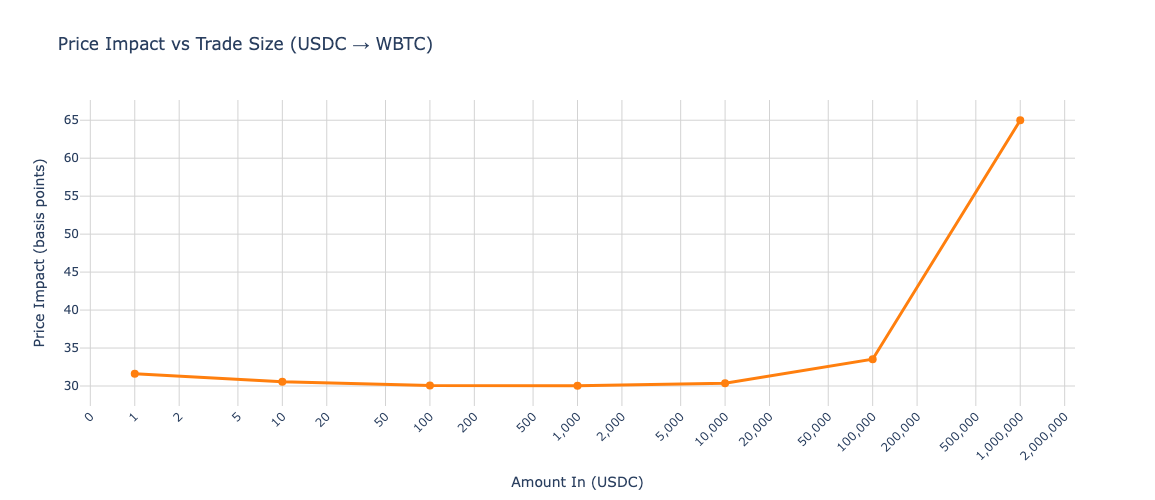

In [33]:
fig2 = plot_price_impact(df, token_in_symbol, token_out_symbol)
fig2.show()

### Cost of Price Impact

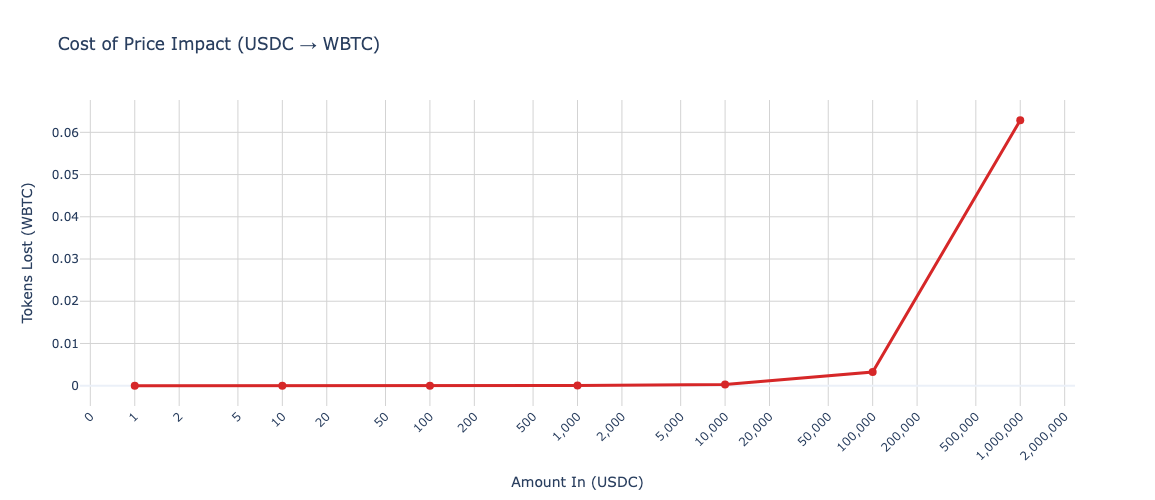

In [34]:
fig3 = plot_cost_of_impact(df, token_in_symbol, token_out_symbol)
fig3.show()

### Combined Analysis

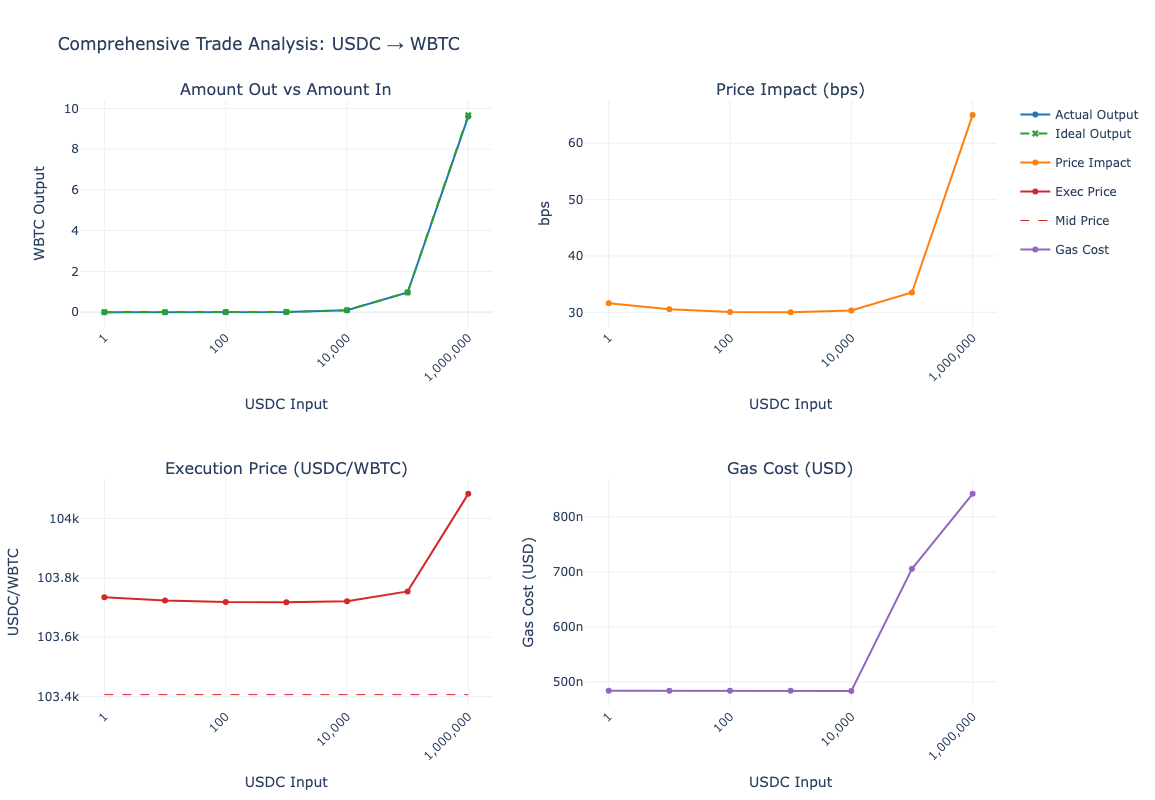

In [35]:
fig4 = plot_combined_analysis(df, token_in_symbol, token_out_symbol)
fig4.show()

## Summary Statistics

In [36]:
# Get pool config for summary (with auto-discovery enabled)
pool_config = get_pool_config(token_in_symbol, token_out_symbol, fee, w3=w3)

# Print summary statistics
print_summary_stats(
    df=df,
    token_in_symbol=token_in_symbol,
    token_out_symbol=token_out_symbol,
    pool_address=pool_config['address'],
    fee=pool_config['fee']
)

Trade Cost Analysis Summary: USDC → WBTC

Pool: 0x99ac8cA7087fA4A2A1FB6357269965A2014ABc35
Fee Tier: 0.3%
ETH Price: $0.00

Trade Size Range: $1 - $1,000,000

Price Impact:
  Min: 30.04 bps (0.30%)
  Max: 64.99 bps (0.65%)
  Mean: 35.88 bps (0.36%)

Execution Price:
  Min: 0.0000096077 WBTC/USDC
  Max: 0.0000096415 WBTC/USDC
  Mid Price: 0.0000096706 WBTC/USDC
  (Inverted) Min: 103718.19 USDC/WBTC
  (Inverted) Max: 104083.04 USDC/WBTC
  (Inverted) Mid Price: 103406.61 USDC/WBTC

Cost of Impact:
  Total tokens lost: 0.06641714 WBTC
  Total USD lost: $6,867.97
  Average cost per trade: $981.14

Gas Costs:
  Min: 84,249 gas ($0.00)
  Max: 146,641 gas ($0.00)
  Mean: 98,689 gas ($0.00)
  Total gas cost: $0.00


## Export Results

In [37]:
# Export to CSV
os.makedirs(os.path.dirname(output_file), exist_ok=True)
df.to_csv(output_file, index=False)
print(f"Results exported to: {output_file}")

Results exported to: ../data/uniswap_trade_costs_USDC_WBTC.csv


## Analyze Different Token Pairs

To analyze different token pairs, simply change the parameters and re-run:

In [38]:
# Example: Analyze USDC -> WETH
# df_weth = analyze_trade_costs(
#     w3=w3,
#     token_in_symbol="USDC",
#     token_out_symbol="WETH",
#     amounts_in=[1, 10, 100, 1000, 10000, 100000],
#     verbose=True
# )
# fig = plot_combined_analysis(df_weth, "USDC", "WETH")
# fig.show()